In [1]:
# why use knn?
#this is used for classification problem,recommendation system,pattern recongnition,regression problem
#ex:movie recommendations,customer segmentation, disease prediction
# what is knn?
#knn works using similarity of data
#how knn works?
#1.choose k value
#2.find those k nearest neighbors
#3.check majority class among neighbors
#4.assign predicted class 
#knn depends upon distance metric
#euclidean distance
#   distance = sqrt((x2-x1)^2 + (y2-y1)^2)

## IMPORT LIBRARIES

In [2]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## LOAD DATASET

In [3]:
# Read Titanic dataset

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## BASIC INFORMATION ABOUT DATASET

In [12]:
# Shape of dataset
df.shape

(891, 12)

In [13]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## CHECK MISSING VALUES

In [16]:
# Check null values in dataset

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## EXPLORATORY DATA ANALYSIS (EDA)

#### Survival Count

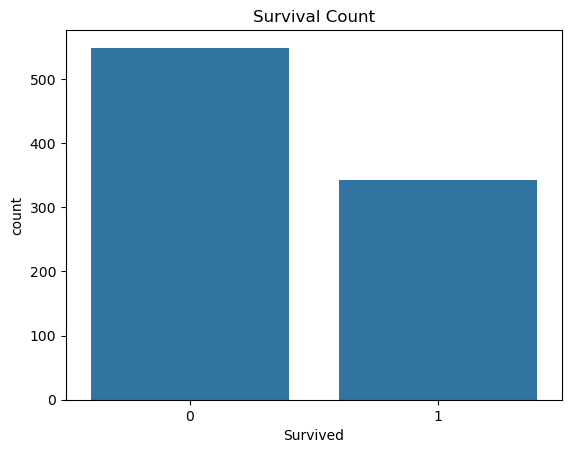

In [17]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()  

#### Gender vs Survival

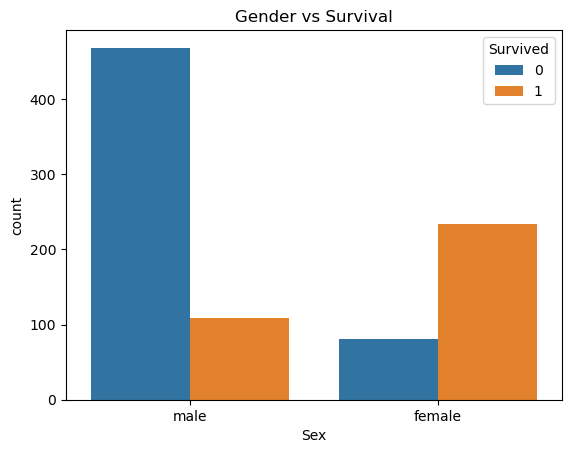

In [18]:
sns.countplot(x='Sex',
              hue='Survived',
              data=df)

plt.title("Gender vs Survival")

plt.show()

#### Passenger Class vs Survival

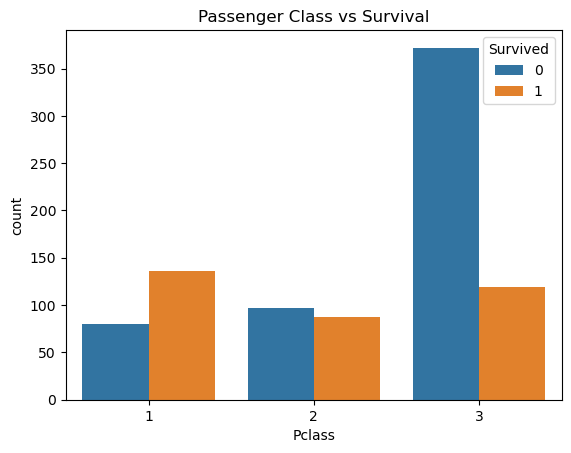

In [19]:
sns.countplot(x='Pclass',
              hue='Survived',
              data=df)

plt.title("Passenger Class vs Survival")

plt.show()

## HANDLE MISSING VALUES

In [20]:
# Fill missing Age values using median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values using mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column because many values are missing
df.drop('Cabin', axis=1, inplace=True)

In [21]:
# Check again
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## ENCODE CATEGORICAL DATA

In [22]:
# Create LabelEncoder object
le = LabelEncoder()

# Convert male/female into numbers
df['Sex'] = le.fit_transform(df['Sex'])

# Convert Embarked values into numbers
df['Embarked'] = le.fit_transform(df['Embarked'])


df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


## FEATURE SELECTION

In [24]:
# Input features

X = df[['Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked']]

# Target/output column

y = df['Survived']

X.head()
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## TRAIN TEST SPLIT

In [25]:
# Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


## FEATURE SCALING

In [26]:
# KNN is distance-based
# So scaling is important

scaler = StandardScaler()

# Scale training data
X_train = scaler.fit_transform(X_train)

# Scale testing data
X_test = scaler.transform(X_test)

## CREATE KNN MODEL

In [27]:
# Create KNN classifier

knn = KNeighborsClassifier(n_neighbors=5)

## TRAIN MODEL

In [28]:
# Train model

knn.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## MAKE PREDICTIONS

In [29]:
# Predict output

y_pred = knn.predict(X_test)

print(y_pred)

[0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1]


## CHECK ACCURACY

In [30]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


[[90 15]
 [20 54]]


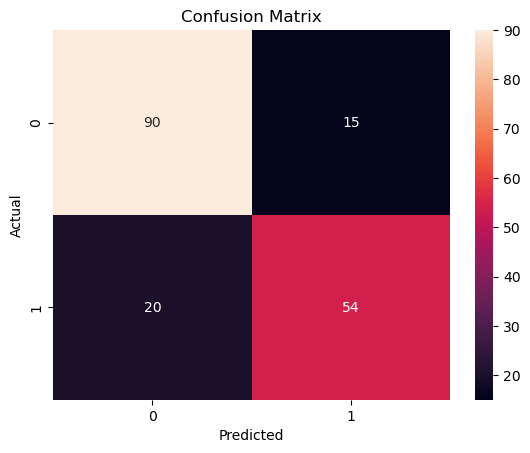

In [32]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

# Visualization

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## CLASSIFICATION REPORT

In [33]:
# Print classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



## FIND BEST K VALUE

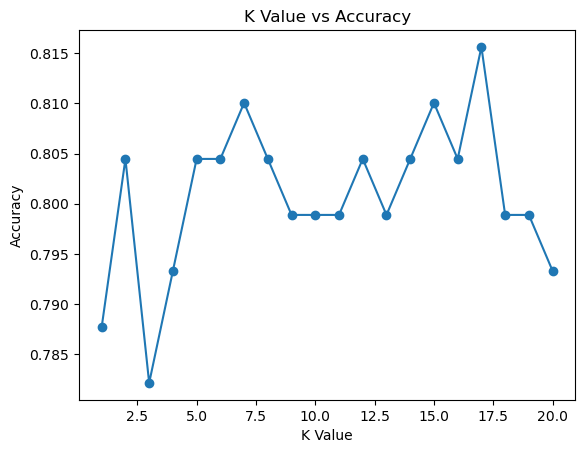

In [35]:
accuracy_list = []

# Try K values from 1 to 20

for k in range(1, 21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    accuracy_list.append(acc)

# Plot graph

plt.plot(range(1, 21),accuracy_list,marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.show()

## LOAD TEST DATASET

In [38]:
# Load test dataset

test_data=pd.read_csv("test.csv")

test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## PREPROCESS TEST DATA

In [40]:
# Fill missing values

test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

test_data['Embarked'] = test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

In [41]:
#check again
test_data.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

In [43]:
# Drop Cabin column

test_data.drop('Cabin', axis=1, inplace=True)

In [44]:
test_data.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [46]:
# Encode categorical columns

test_data['Sex'] = le.fit_transform(test_data['Sex'])

test_data['Embarked'] = le.fit_transform(test_data['Embarked'])

## SELECT TEST FEATURES

In [48]:
X_final = test_data[['Pclass',
                   'Sex',
                   'Age',
                   'SibSp',
                   'Parch',
                   'Fare',
                   'Embarked']]

## SCALE TEST DATA

In [49]:
# Scale test data

X_final = scaler.transform(X_final)

## FINAL PREDICTIONS

In [50]:
# Predict final output

final_predictions = knn.predict(X_final)

print(final_predictions)

[0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0 0
 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0
 1 0 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 0
 1 1 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 1 0 1 0 0 1 0 0 1 1 0 1 1 1 1 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 0 0 1 0 1
 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 1 1 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 0 1 0
 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 0 0
 0 1 1 1 1 0 1 1 0 1 0]
